In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Darwin':  # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')

# 마이너스 기호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 상수 정의
RAINBOW_COLORS = [
    "#FF0000", # 빨 (Mon)
    "#FF7F00", # 주 (Tue)
    "#FFD700", # 노 (Wed)
    "#1DC11D", # 초 (Thu)
    "#6969E4", # 파 (Fri)
    "#A049DF", # 남 (Sat)
    "#DB47A2"  # 보 (Sun)
]
DAY_MAP = {1: '월', 2: '화', 3: '수', 4: '목', 5: '금', 6: '토', 7: '일'}
DAY_ORDER = ['월', '화', '수', '목', '금', '토', '일']
WEEKDAYS = [1, 2, 3, 4, 5]
WEEKEND = [6, 7]
TARGET_STATION = '역삼역'
CAR_RANGE = range(1, 11)

# 그래프 설정 상수
GRAPH_CONFIG = {
    'boxplot': {
        'width': 0.6,
        'markersize': 6,
        'fliersize': 3
    },
    'lineplot': {
        'markersize': 8,
        'linewidth': 2.5
    },
    'figure': {
        'dual_size': (20, 16),
        'single_size': (20, 8)
    }
}

In [9]:
df = pd.read_csv('../data/train_congestion_data.csv')
df.head()

,congestion_id,created_at,updated_at,congestion_cars,day_of_week,direction,measured_at,stat_end_date,stat_start_date,station_id,station_id.1,created_at.1,line_name,station_code,station_name,updated_at.1,latitude,longitude
0,135337,2026-01-25 13:07:46.493703,2026-01-25 13:07:46.493703,"[71, 70, 63, 83, 74, 65, 61, 67, 47, 40]",1,0,17:40:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
1,135338,2026-01-25 13:07:46.495483,2026-01-25 13:07:46.495483,"[63, 54, 65, 66, 55, 65, 75, 54, 52, 41]",1,1,17:30:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
2,135342,2026-01-25 13:07:46.505253,2026-01-25 13:07:46.505253,"[40, 47, 44, 48, 39, 55, 48, 39, 49, 30]",1,1,17:50:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
3,135345,2026-01-25 13:07:46.510723,2026-01-25 13:07:46.510723,"[50, 66, 60, 72, 63, 58, 64, 60, 48, 28]",1,0,17:30:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
4,135346,2026-01-25 13:07:46.512792,2026-01-25 13:07:46.512792,"[53, 60, 64, 61, 62, 63, 67, 58, 56, 44]",1,1,17:40:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174


In [10]:
def draw_car_boxplot(df_input, direction_val, title_suffix):
    # 1. 전처리
    df_filtered = df_input[
        (df_input['station_name'] == '역삼역') & 
        (~df_input['day_of_week'].isin([6, 7])) & 
        (df_input['direction'] == direction_val)
    ].copy()

    # 2. 문자열 리스트 변환
    df_filtered['congestion_cars'] = df_filtered['congestion_cars'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # 3. 데이터 구조 재구성
    plot_data = []
    for _, row in df_filtered.iterrows():
        for car_idx, val in enumerate(row['congestion_cars'], start=1):
            plot_data.append({
                '시간': str(row['measured_at'])[:5],
                '칸': car_idx,
                '혼잡도': val
            })
    df_plot = pd.DataFrame(plot_data).sort_values(by='시간')

    # 4. 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(20, 16))
    
    # [첫 번째 그래프] 박스플롯
    sns.boxplot(
        data=df_plot, 
        x='칸', 
        y='혼잡도', 
        hue='시간',
        palette=RAINBOW_COLORS,
        width=0.6,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "6"},
        flierprops={"markersize": 3},
        ax=axes[0]
    )
    axes[0].set_title(f'역삼역 평일 칸별 혼잡도 분포 (Boxplot) - {title_suffix}', fontsize=16)
    axes[0].set_xlabel('') 
    axes[0].set_ylabel('혼잡도 (%)', fontsize=12)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    axes[0].legend(title='측정 시간')

    # [두 번째 그래프] 라인플롯
    sns.lineplot(
        data=df_plot,
        x='칸',
        y='혼잡도',
        hue='시간',
        palette=RAINBOW_COLORS,
        estimator='mean',
        errorbar=None,
        marker='o',
        markersize=8,
        linewidth=2.5,
        ax=axes[1]
    )
    axes[1].set_title(f'역삼역 평일 칸별 혼잡도 평균 추세 (Lineplot) - {title_suffix}', fontsize=16)
    axes[1].set_xlabel('열차 칸 번호 (1-10)', fontsize=12)
    axes[1].set_ylabel('평균 혼잡도 (%)', fontsize=12)
    axes[1].grid(True, axis='both', linestyle='--', alpha=0.5)
    axes[1].legend(title='측정 시간')
    axes[1].set_xticks(range(1, 11))
    axes[1].set_xticklabels(range(1, 11))
    axes[1].set_xlim(0.5, 10.5)

    plt.tight_layout()
    plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast

def draw_weekly_detail_plots_combined(df_input, direction_val, title_suffix):
    
    # DAY_MAP의 Key, Value를 뒤집어서 {'월': 1, '화': 2 ...} 형태로 변환
    day_name_to_idx = {v: k for k, v in DAY_MAP.items()}

    # 평일('월'~'금') 추출
    target_weekdays = [d for d in DAY_ORDER if d in ['월', '화', '수', '목', '금']]
    
    # -------------------------------------------------------
    # [핵심 변경] 5개의 그래프를 담을 하나의 큰 Figure 생성
    # nrows=5: 5줄, ncols=1: 1칸
    # figsize=(20, 30): 세로 길이를 넉넉하게 주어 그래프가 찌그러지지 않게 함
    # -------------------------------------------------------
    fig, axes = plt.subplots(nrows=len(target_weekdays), ncols=1, figsize=(20, 30))
    
    # 데이터가 아예 없거나 요일이 적을 경우 axes가 배열이 아닐 수 있어 처리
    if len(target_weekdays) == 1:
        axes = [axes]

    # 요일별 루프 (enumerate를 사용하여 인덱스 i와 요일 이름을 같이 가져옴)
    for i, day_name in enumerate(target_weekdays):
        
        ax = axes[i] # 현재 요일에 해당하는 그래프 영역(axis) 선택
        day_code = day_name_to_idx[day_name]

        # 1. [필터링]
        df_filtered = df_input[
            (df_input['station_name'] == '역삼역') & 
            (df_input['day_of_week'] == day_code) & 
            (df_input['direction'] == direction_val)
        ].copy()
        
        # 데이터가 없을 경우 빈 그래프에 텍스트 표시 후 넘어감
        if df_filtered.empty:
            ax.text(0.5, 0.5, f'[{day_name}] 데이터 없음', 
                    horizontalalignment='center', verticalalignment='center', fontsize=15)
            ax.set_title(f'[{day_name}] - 데이터 없음')
            continue

        # 2. [데이터 변환]
        df_filtered['congestion_cars'] = df_filtered['congestion_cars'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

        # 3. [구조 재구성]
        plot_data = []
        for _, row in df_filtered.iterrows():
            for car_idx, val in enumerate(row['congestion_cars'], start=1):
                plot_data.append({
                    '시간': str(row['measured_at'])[:5],
                    '칸': car_idx,
                    '혼잡도': val
                })
        df_plot = pd.DataFrame(plot_data).sort_values(by='시간')

        # 4. [그래프 그리기] - ax 파라미터 사용
        sns.lineplot(
            data=df_plot,
            x='칸',
            y='혼잡도',
            hue='시간',
            palette=RAINBOW_COLORS,
            estimator='mean',
            errorbar=None,
            marker='o',
            markersize=8,
            linewidth=2.5,
            ax=ax  # <--- 중요: 현재 루프의 axis에 그림
        )
        
        # 그래프 꾸미기 (plt.title 대신 ax.set_title 사용)
        ax.set_title(f'[{day_name}] 역삼역 칸별 혼잡도 평균 추세 - {title_suffix}', fontsize=16)
        ax.set_xlabel('열차 칸 번호 (1-10)', fontsize=12)
        ax.set_ylabel('평균 혼잡도 (%)', fontsize=12)
        ax.grid(True, axis='both', linestyle='--', alpha=0.5)
        ax.legend(title='측정 시간')
        
        # 축 설정
        ax.set_xticks(range(1, 11))
        ax.set_xlim(0.5, 10.5)

    # 전체 레이아웃 조절 (그래프 간 간격 자동 조정)
    plt.tight_layout()
    plt.show()

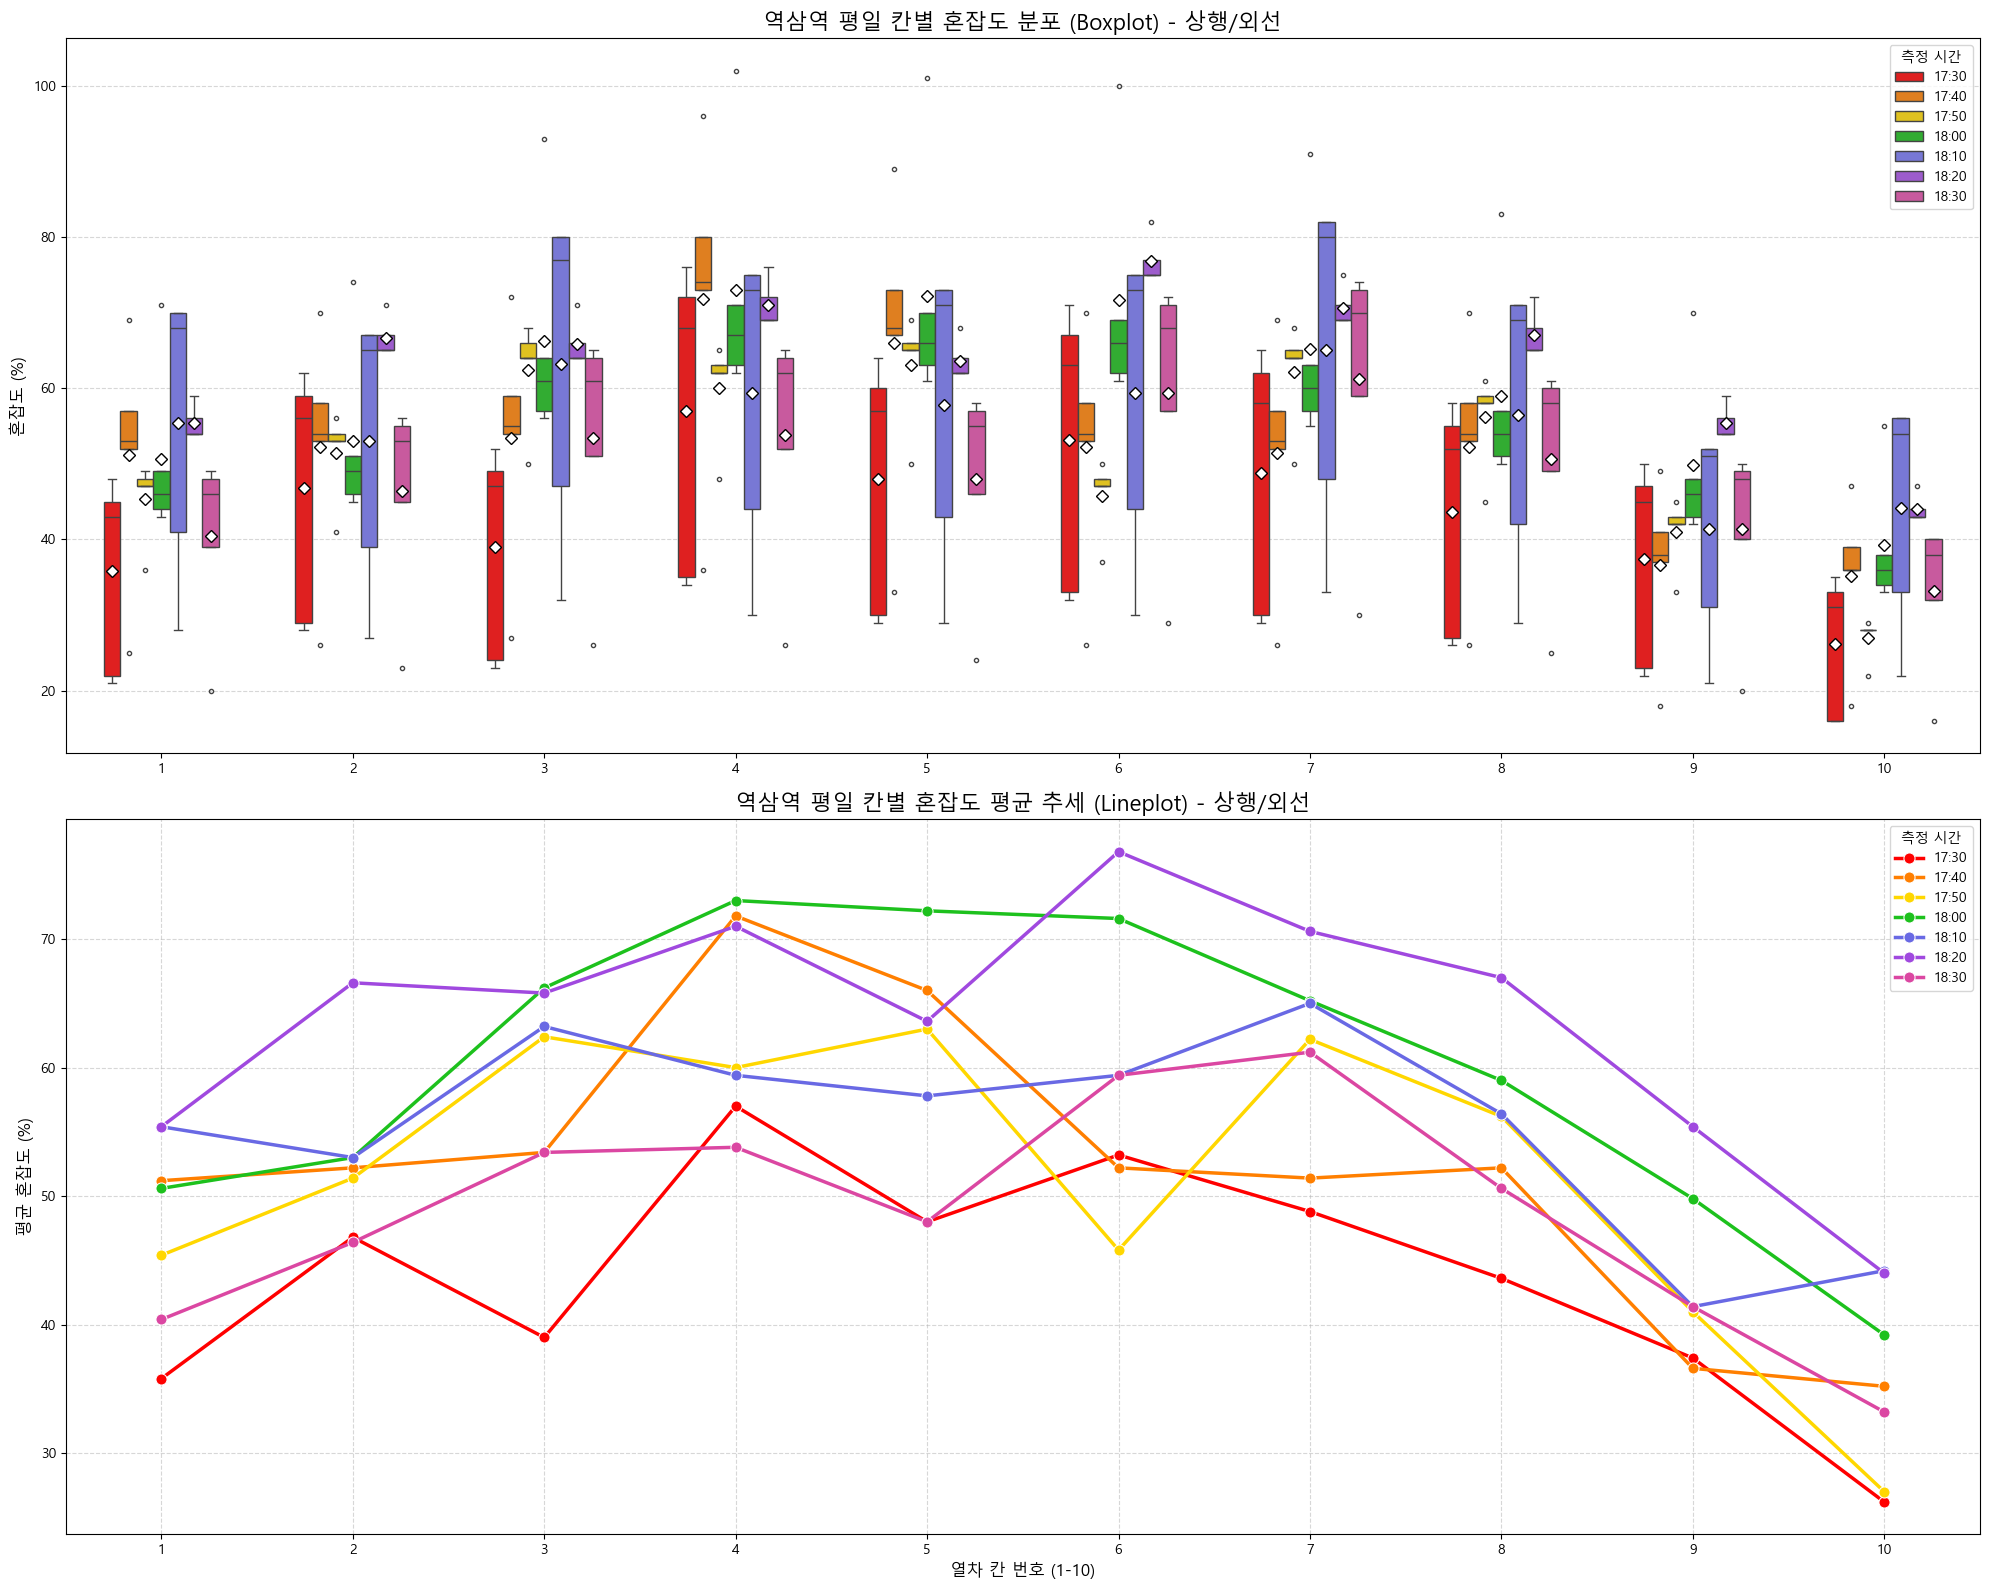

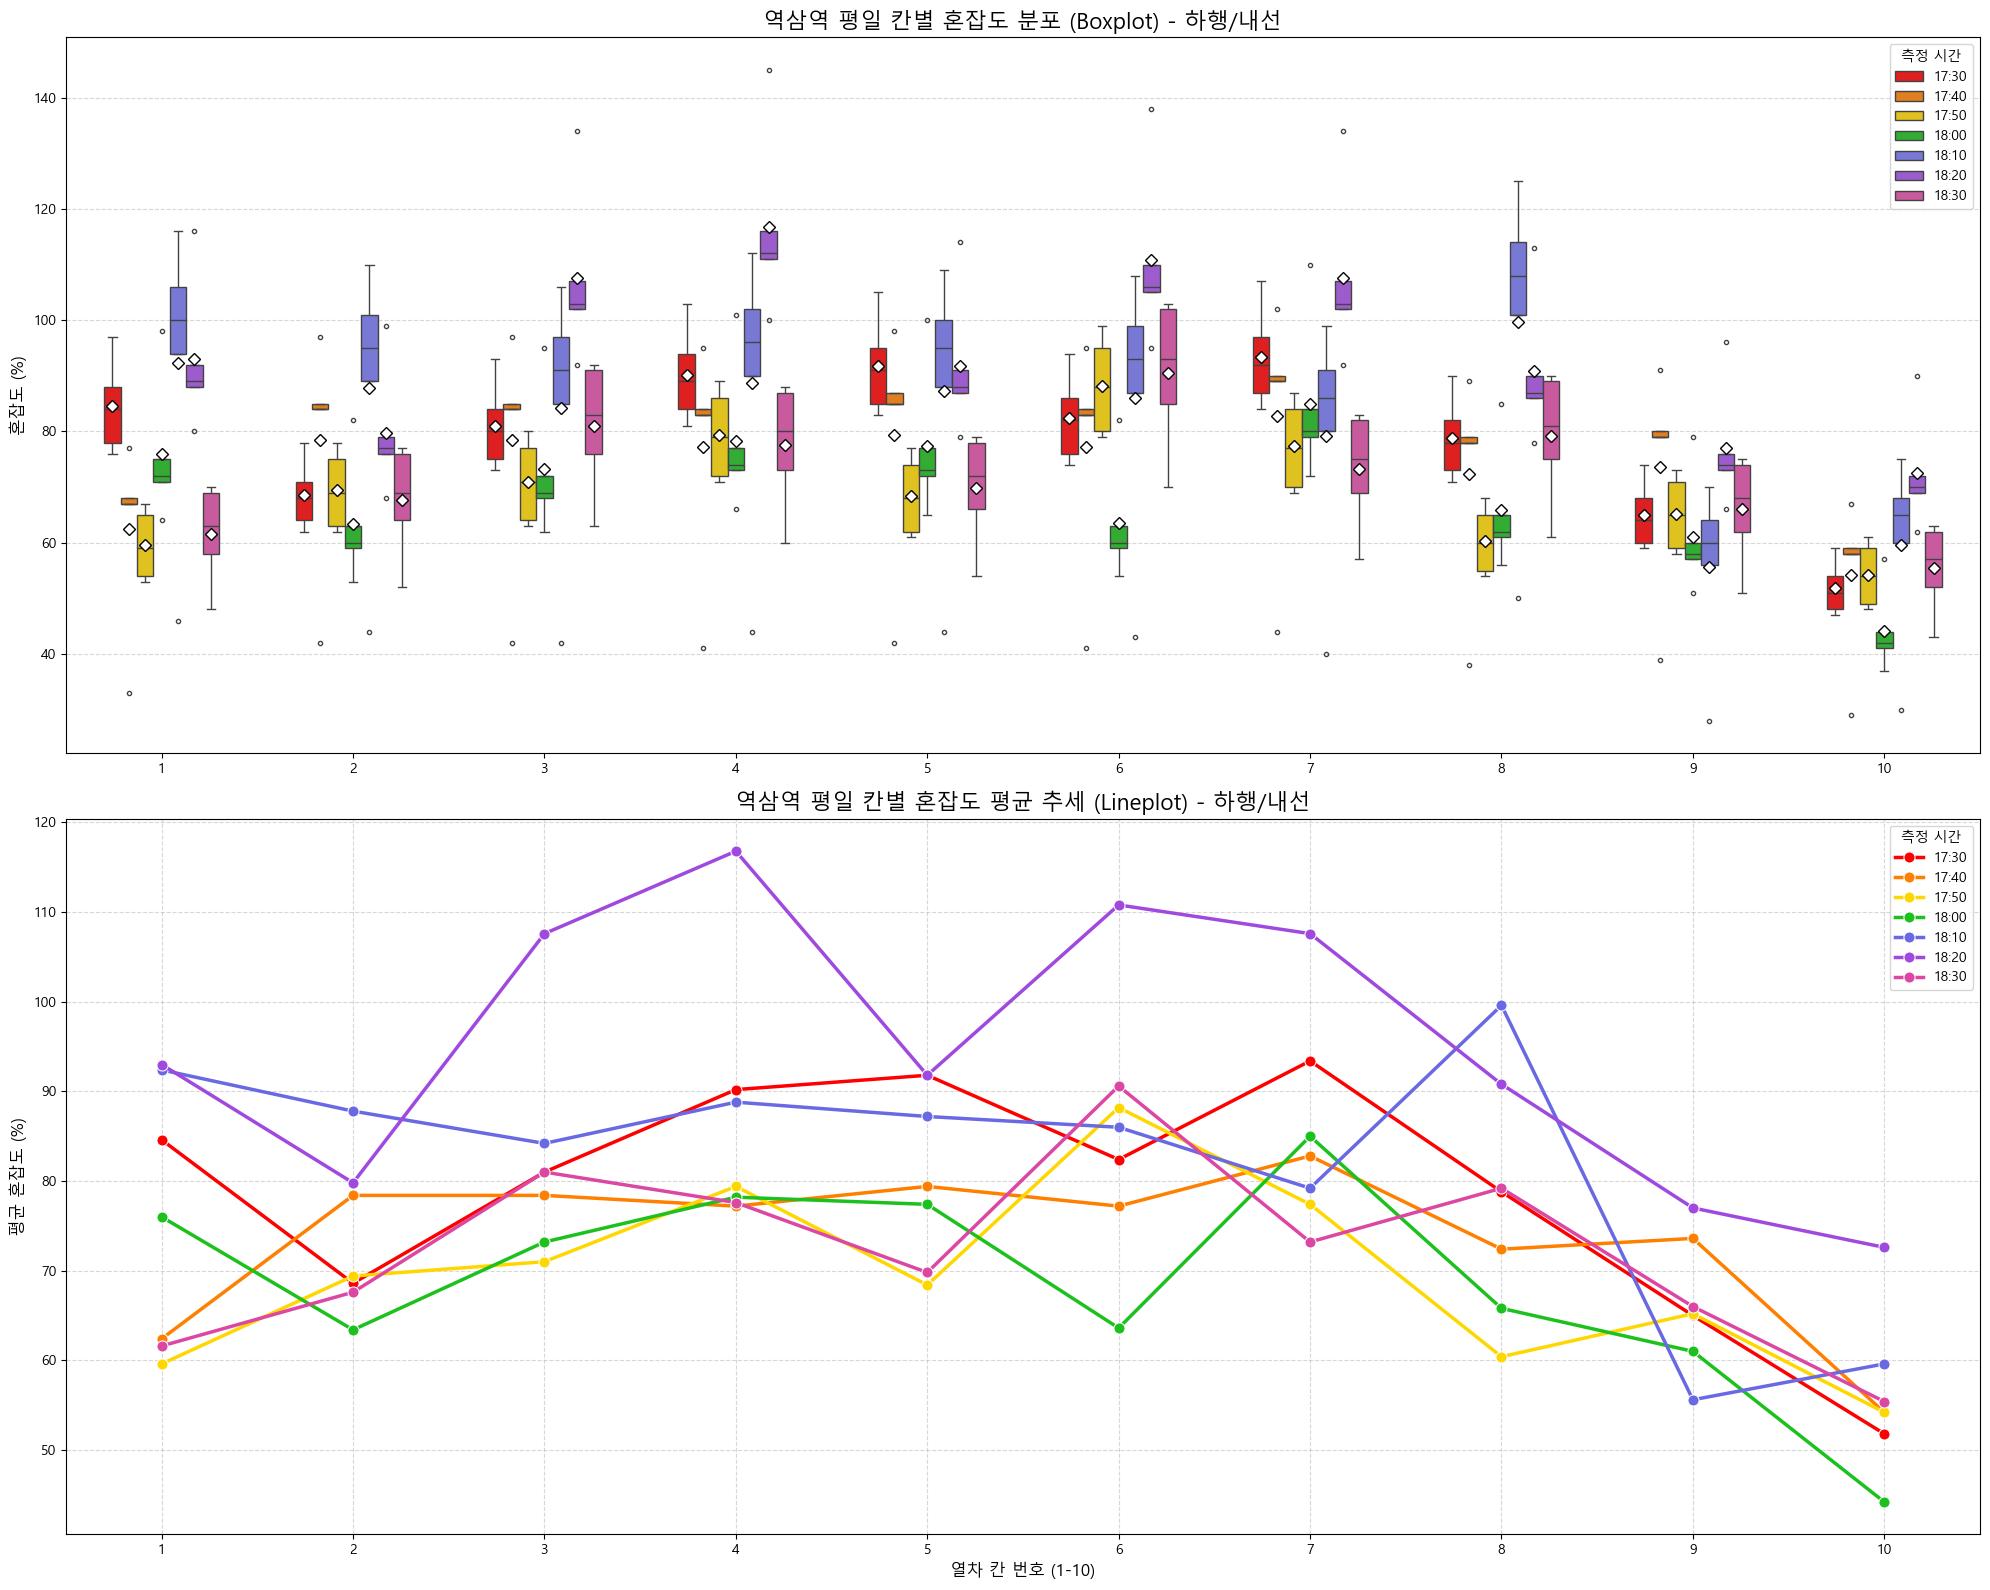

1. 상행/외선 통합 그래프


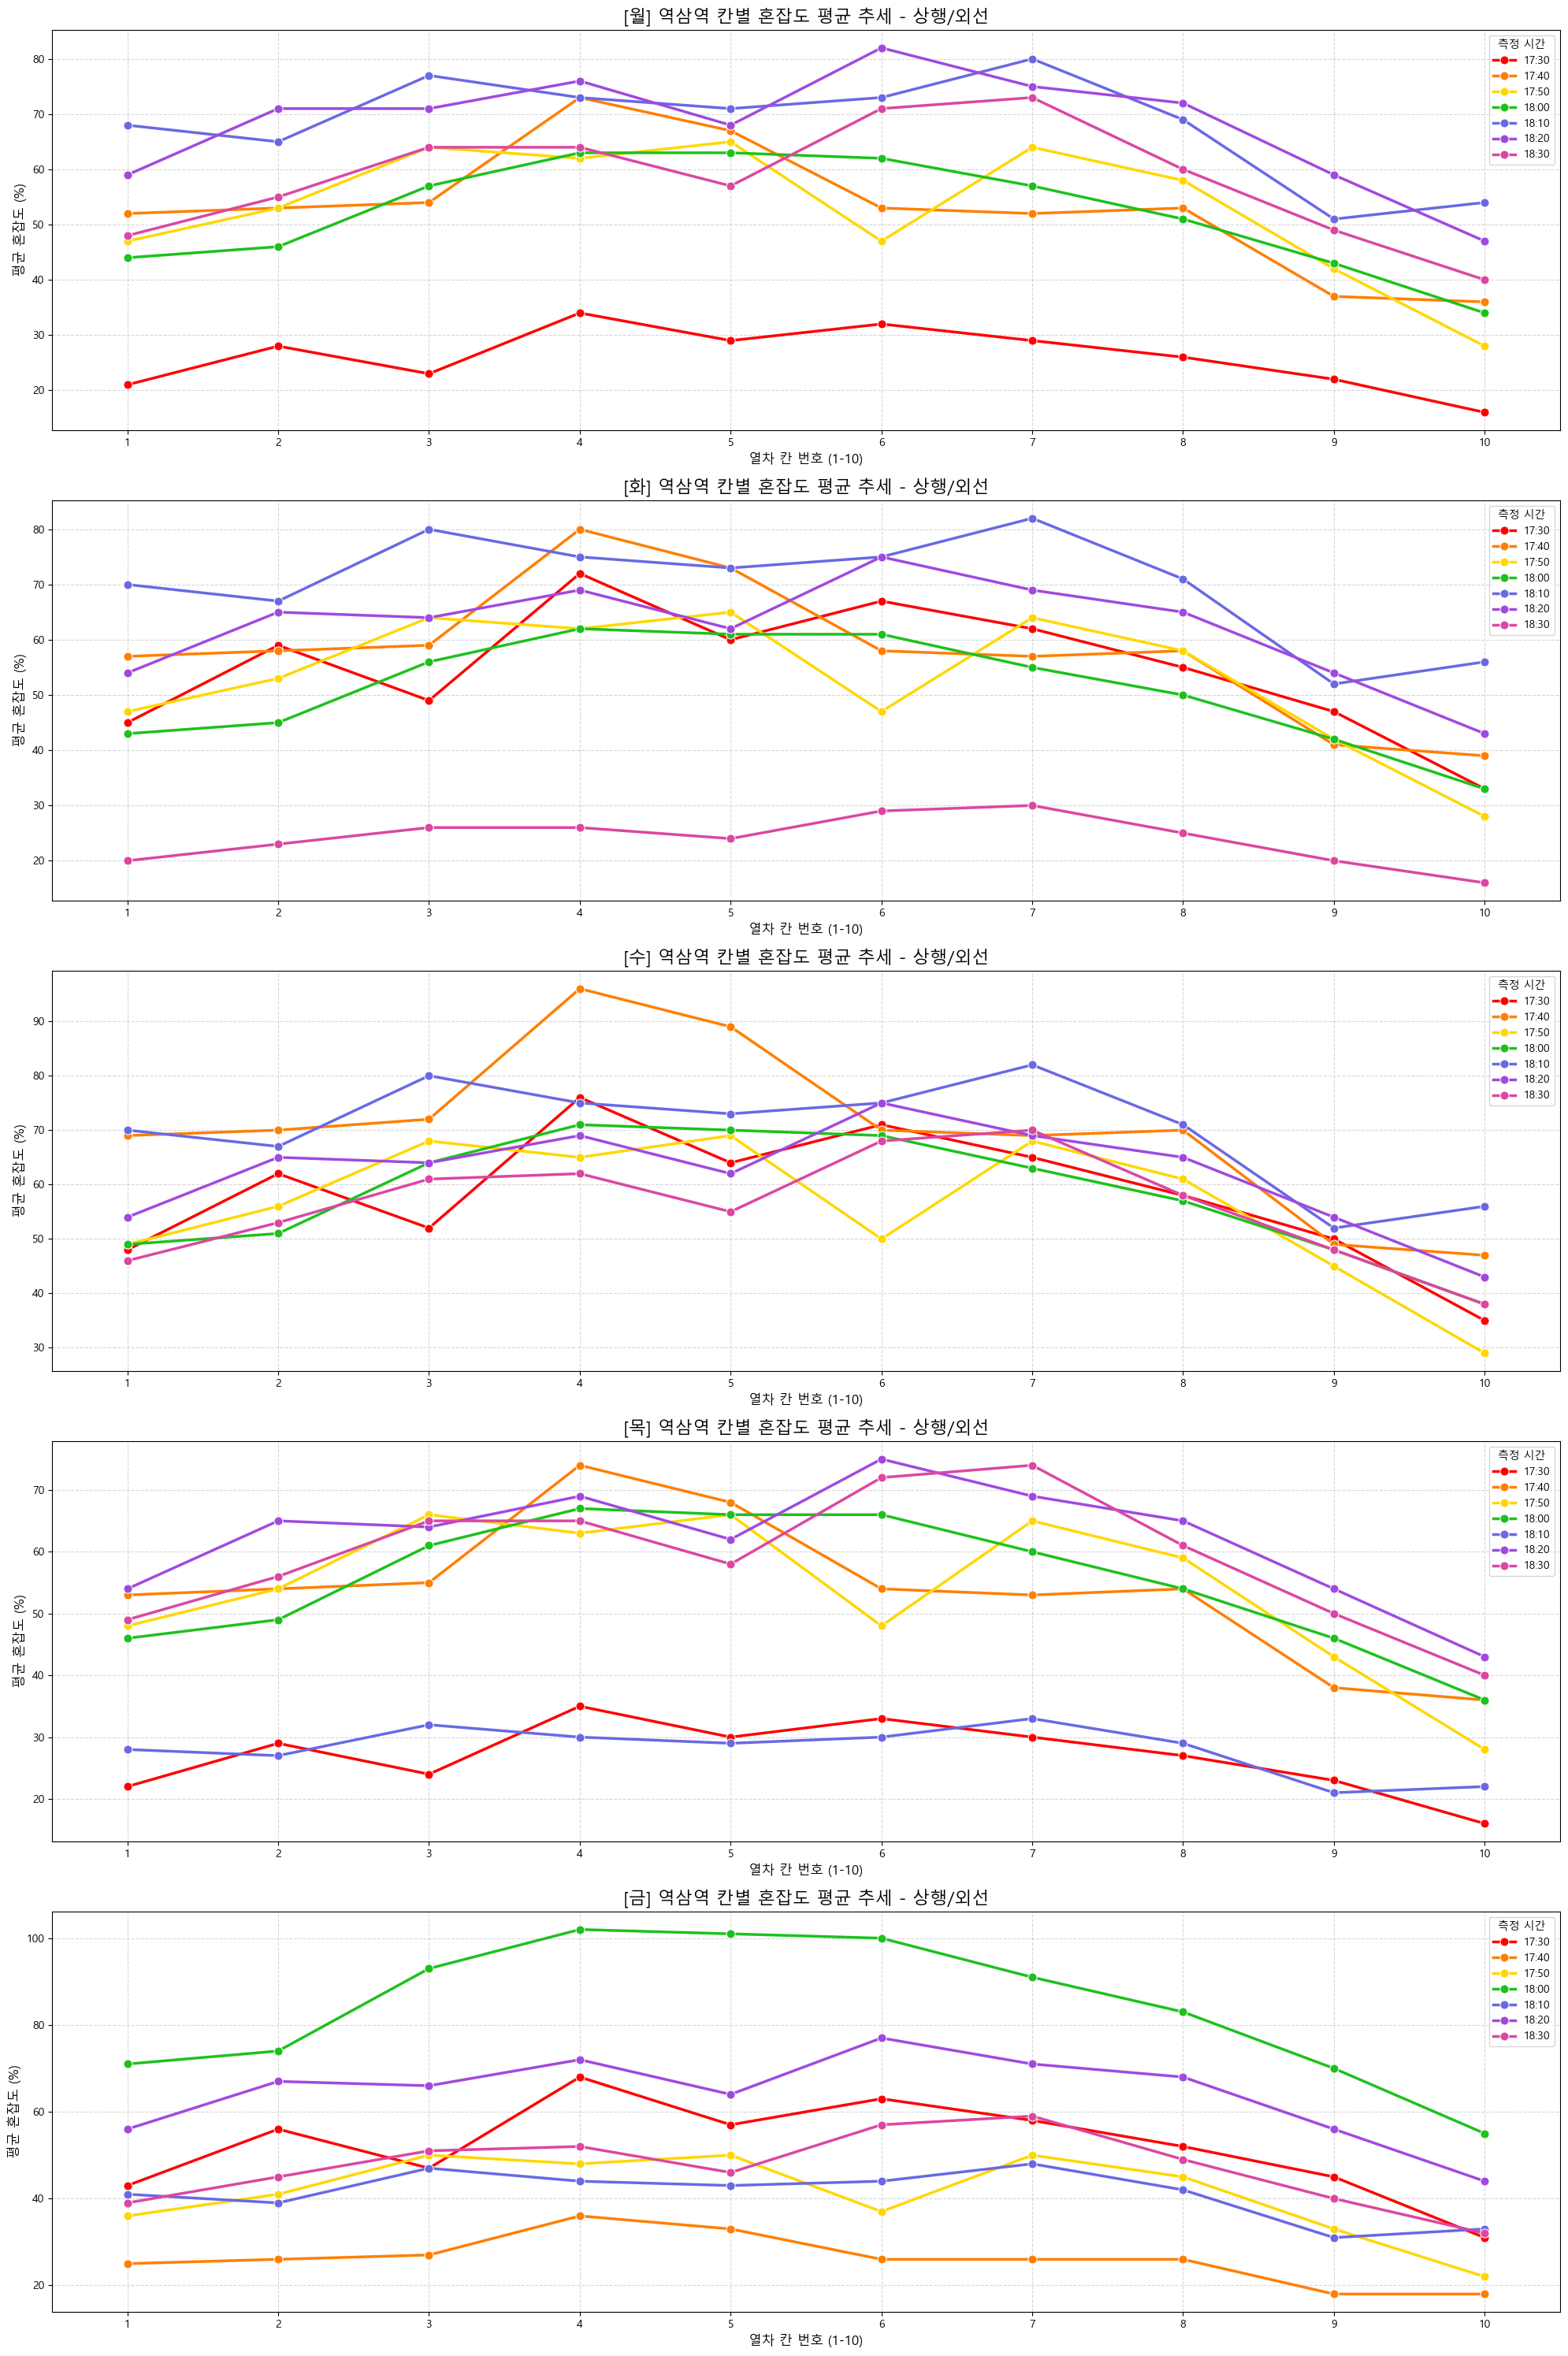


2. 하행/내선 통합 그래프


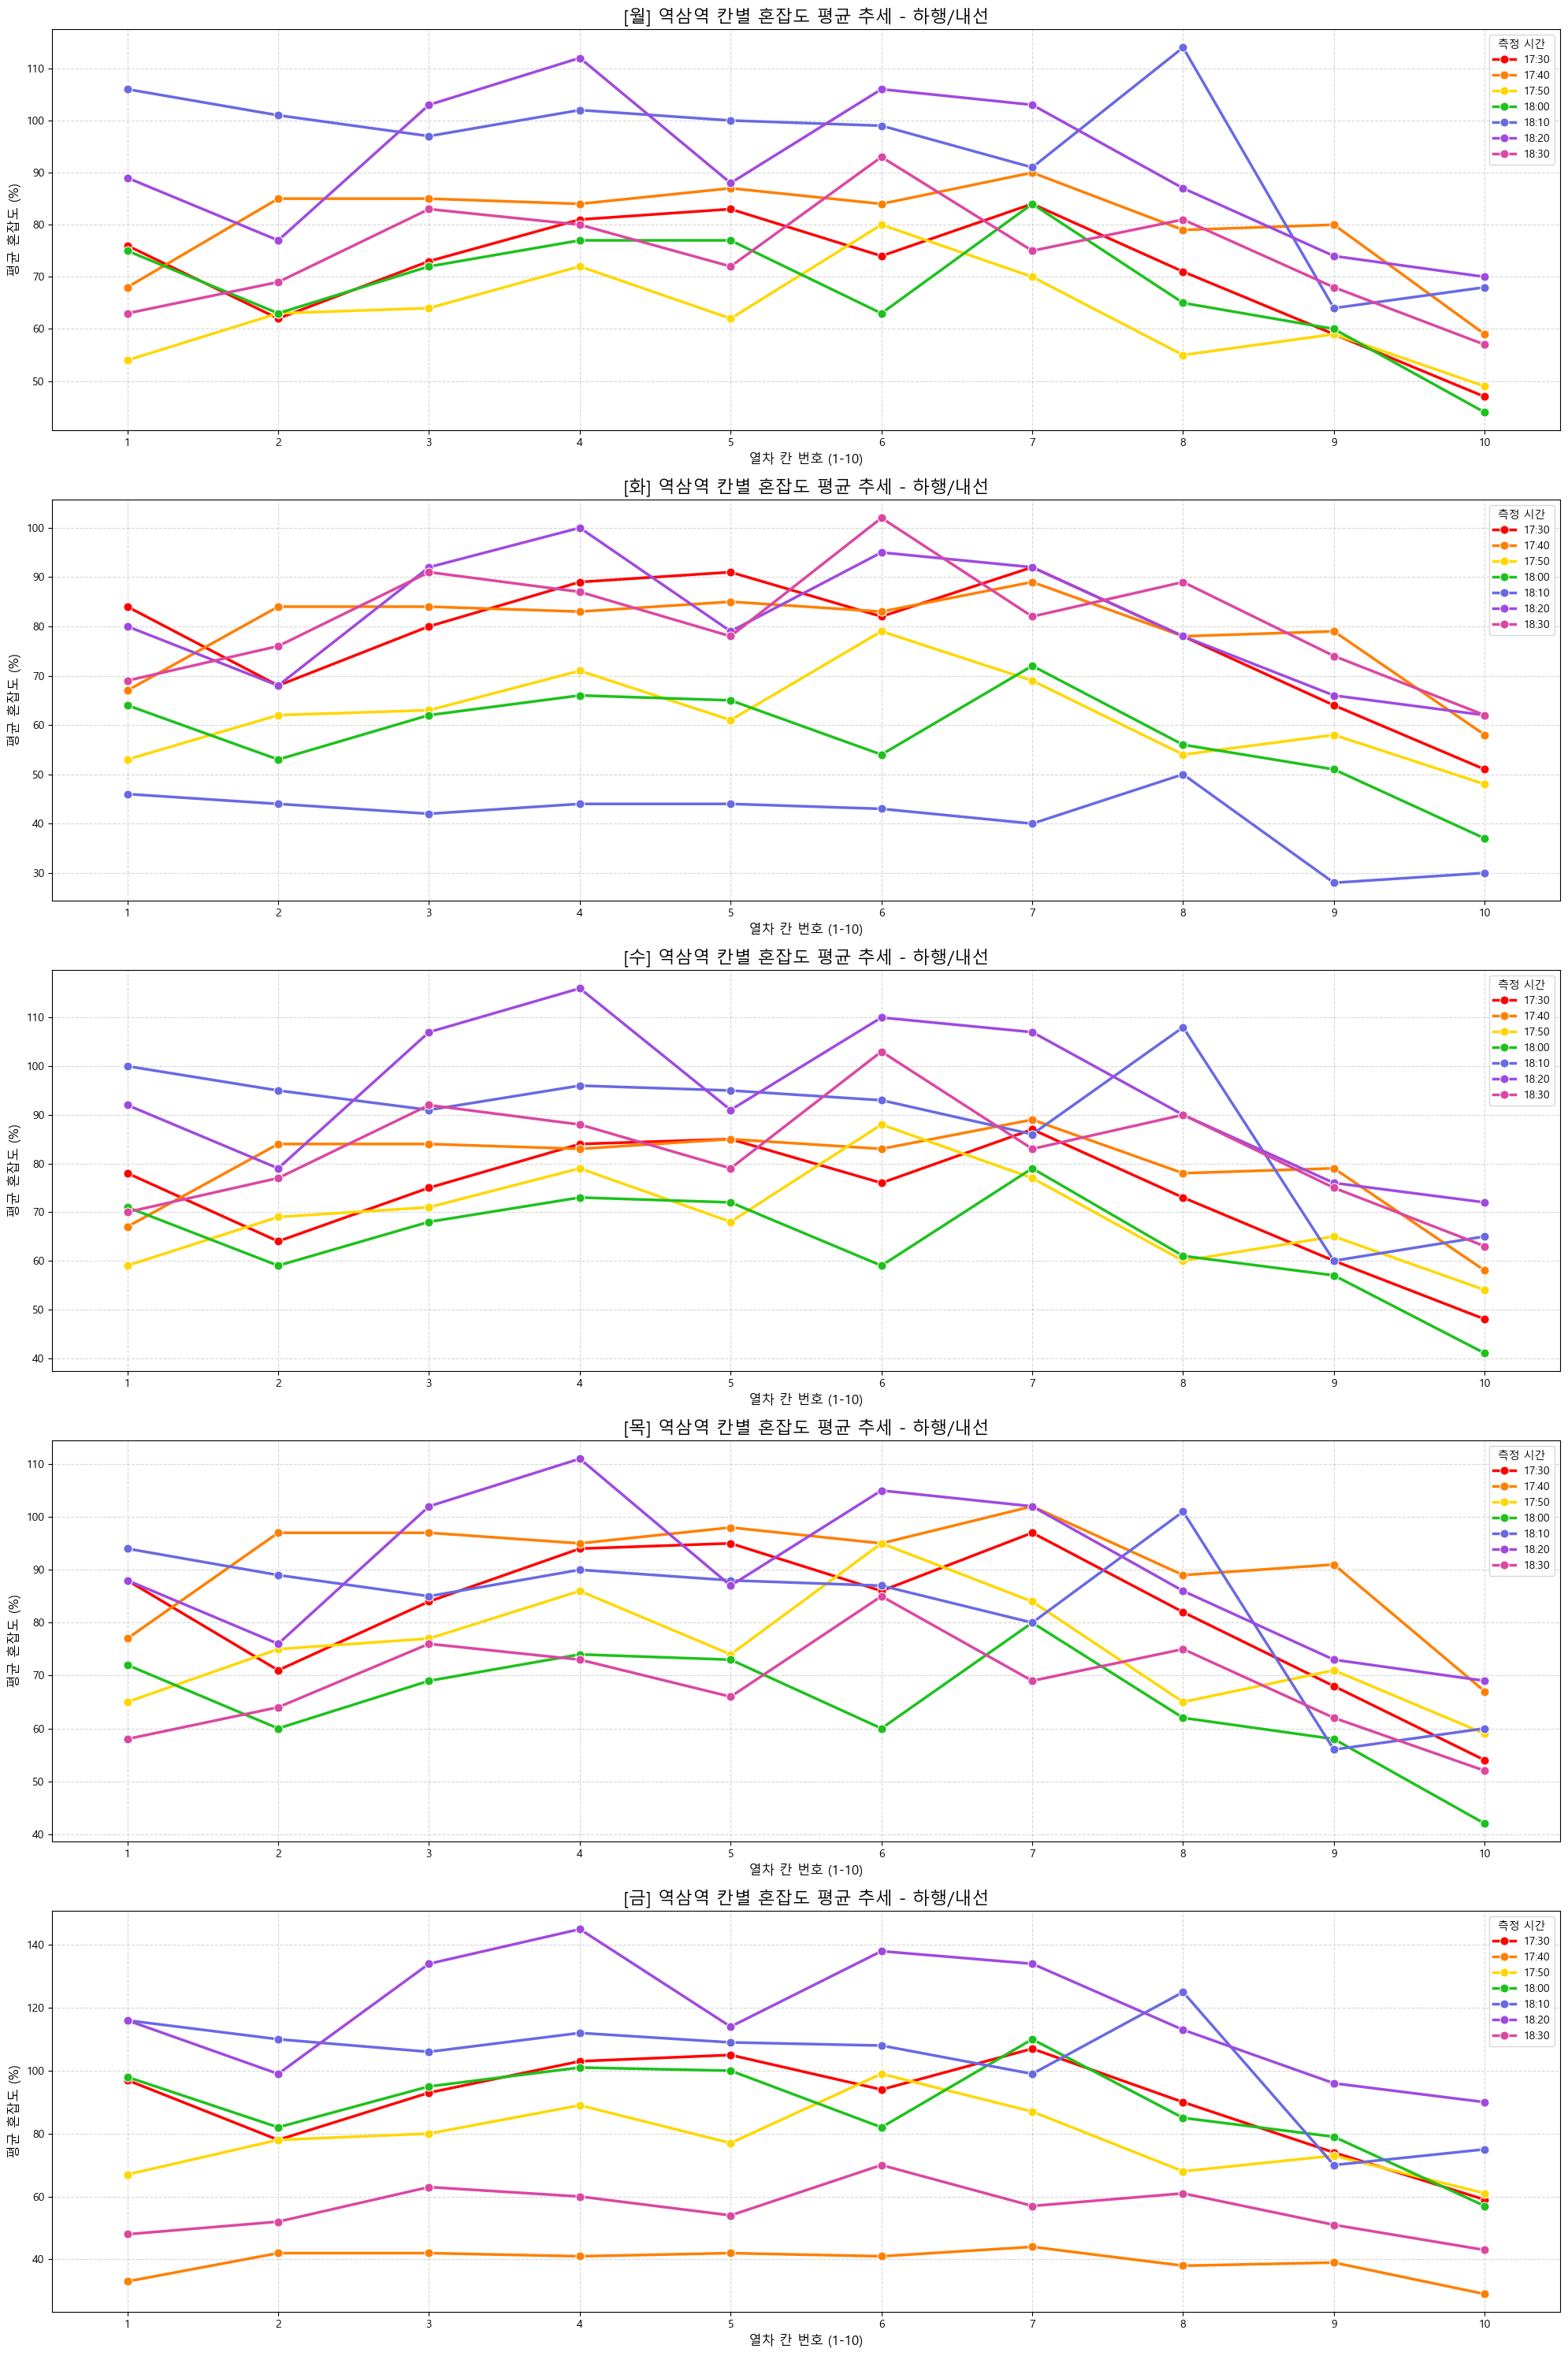

In [12]:
# 실행
draw_car_boxplot(df, 0, "상행/외선")
draw_car_boxplot(df, 1, "하행/내선")


print("="*50)
print("1. 상행/외선 통합 그래프")
print("="*50)
draw_weekly_detail_plots_combined(df, 0, "상행/외선")

print("\n" + "="*50)
print("2. 하행/내선 통합 그래프")
print("="*50)
draw_weekly_detail_plots_combined(df, 1, "하행/내선")